# Generalizability

In [290]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [273]:
experiment = "generalizability"
dataset = "aitv2"
scenario = "santos"

In [274]:
experiments = {}

In [275]:
metrics_dir = Path(f"../../experiments_old/{dataset}/{experiment}/deepproblog/metrics")
file_paths = list(metrics_dir.iterdir())

f1_scores = {}
false_positives = {}
detection_rates = {}

for file_path in file_paths:
    experiment_name = str(file_path.stem)

    # print(f"Processing {experiment_name}...")
    data = np.load(file_path, allow_pickle=True)
    metrics = data["metrics"].item()

    exp_name = f"dpl_{experiment_name}"
    experiments[exp_name] = {
        "f1_score": metrics["macro_f1"],
        "false_alarm_rate": metrics["false_alarm_rate"],
        "detection_rate": metrics["detection_rate"]
    }


In [276]:
metrics_dir = Path(f"../../experiments_old/{dataset}/{experiment}/baselines/metrics")
file_paths = list(metrics_dir.iterdir())

for file_path in file_paths:
    experiment_name = str(file_path.stem)
    
    # print(f"Processing {experiment_name}...")
    with open(file_path) as f:
        metrics = json.load(f)
    
    exp_name = f"baseline_{experiment_name}"

    experiments[exp_name] = {
        "f1_score": metrics["Macro F1"],
        "false_alarm_rate": metrics["False Alarm Rate"],
        "detection_rate": metrics["Detection Rate"]
    }


In [277]:
experiments

{'dpl_fox_pretrained': {'f1_score': 0.8798152850175956,
  'false_alarm_rate': 4.374835943652113e-05,
  'detection_rate': 0.9990169919955062},
 'dpl_santos_fox_logic_baseline': {'f1_score': 0.6446858921650247,
  'false_alarm_rate': 0.11790557854080472,
  'detection_rate': 0.9998455273135796},
 'dpl_santos_fox_pretrained': {'f1_score': 0.5039456473375399,
  'false_alarm_rate': 0.000369986125520293,
  'detection_rate': 0.4760707765763236},
 'dpl_fox_scratch': {'f1_score': 0.7024739753291103,
  'false_alarm_rate': 0.0008874667199980001,
  'detection_rate': 0.9927327622524926},
 'dpl_santos_fox_scratch': {'f1_score': 0.7856257534611599,
  'false_alarm_rate': 0.007227228978913291,
  'detection_rate': 0.9959134952956046},
 'baseline_fox': {'f1_score': 0.8585183136300151,
  'false_alarm_rate': 0.00024374085971776057,
  'detection_rate': 0.9988413328183702},
 'baseline_santos_fox': {'f1_score': 0.5352381139387197,
  'false_alarm_rate': 0.1029936377385848,
  'detection_rate': 0.5771845138410009}

In [278]:
plots_dir = Path(f"../../reports/{dataset}/{scenario}/{experiment}")

In [ ]:
def metrics_heatmap(
    experiments,
    selected_models=None,
    global_bounds=None,
    plots_title="",
    plots_dir=None,
    plots_name=""
):

    metrics = ["f1_score", "detection_rate", "false_alarm_rate"]

    metric_labels = ["Macro F1", "Detection Rate", "False Alarm Rate"]

    colormaps = {
        "f1_score": sns.color_palette("RdYlGn", as_cmap=True),
        "detection_rate": sns.color_palette("RdYlGn", as_cmap=True),
        "false_alarm_rate": sns.color_palette("RdYlGn", as_cmap=True),
    }

    if selected_models is None:
        selected_models = list(experiments.keys())

    model_labels = [
        m.replace("dpl_", "")
         .replace("baseline_", "")
         .replace("_scratch", "")
         .replace("_pretrained", "")
         .replace("_logic_baseline", "LOGIC BASELINE")
         .replace("santos_fox", "SANTOS -> FOX \n")
         .replace("fox", "FOX -> FOX \n")
        for m in selected_models
    ]

    data = np.array([
        [experiments[m][metric] for metric in metrics]
        for m in selected_models
    ])

    data_norm = np.zeros_like(data, dtype=float)
    for j, metric in enumerate(metrics):
        vmin, vmax = global_bounds[metric]
        col = data[:, j]
        col = np.clip(col, vmin, vmax)
        data_norm[:, j] = col - vmin

    # Plot
    sns.set_theme(style="white")
    
    fig_height = max(1.8, len(selected_models) * 0.65)
    fig, ax = plt.subplots(figsize=(7.5, fig_height))

    sns.heatmap(
        data_norm,
        cmap="Greys",   # placeholder; we override per-cell coloring below
        cbar=False,
        linewidths=1.5,
        linecolor="white",
        ax=ax
    )

    for i in range(data.shape[0]):
        for j, metric in enumerate(metrics):

            vmin, vmax = global_bounds[metric]
            val = data[i, j]

            if metric == "false_alarm_rate":
                norm_val = (vmax - np.clip(val, vmin, vmax)) / (vmax - vmin)
            else:
                norm_val = (np.clip(val, vmin, vmax) - vmin) / (vmax - vmin)

            color = colormaps[metric](norm_val)

            ax.add_patch(plt.Rectangle(
                (j, i), 1, 1,
                facecolor=color,
                edgecolor="white",
                linewidth=1.5
            ))

            ax.text(
                j + 0.5,
                i + 0.5,
                f"{val:.3f}",
                ha="center",
                va="center",
                fontsize=10,
                color="black" if norm_val < 0.6 else "white"
            )

    # Labels
    ax.set_xticklabels(metric_labels, rotation=0, fontsize=11)

    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    
    ax.set_yticklabels(model_labels, rotation=0, fontsize=10)

    ax.set_title(plots_title, fontsize=12, pad=18)

    plt.tight_layout()

    if plots_dir:
        plots_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(plots_dir / f"metrics_heatmap_{plots_name}.png", dpi=300, bbox_inches="tight")

    plt.show()

In [280]:
for exp_name in experiments.keys():
    print(exp_name)

dpl_fox_pretrained
dpl_santos_fox_logic_baseline
dpl_santos_fox_pretrained
dpl_fox_scratch
dpl_santos_fox_scratch
baseline_fox
baseline_santos_fox


In [281]:
def compute_global_bounds(experiments, metrics):
    bounds = {}

    for metric in metrics:
        values = [
            experiments[m][metric]
            for m in experiments
        ]

        if metric == "false_alarm_rate":
            bounds[metric] = (0.0, max(values))  # often better to anchor at 0
        else:
            bounds[metric] = (min(values), max(values))

    return bounds

In [282]:
bounds = compute_global_bounds(experiments, metrics=["f1_score", "detection_rate", "false_alarm_rate"])

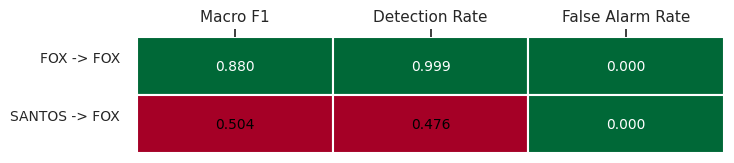

In [283]:
top_models = [
    "dpl_fox_pretrained",
    "dpl_santos_fox_pretrained",
]

metrics_heatmap(
    experiments,
    selected_models=top_models,
    global_bounds=bounds,
    # plots_title="DeepProbLog Pretrained",
    plots_dir=plots_dir,
    plots_name="dpl_pretrained"
)

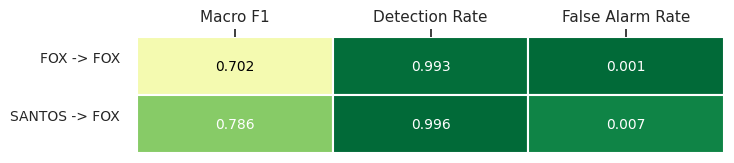

In [284]:
top_models = [
    "dpl_fox_scratch",
    "dpl_santos_fox_scratch",
    # "dpl_santos_fox_logic_baseline",
]

metrics_heatmap(
    experiments,
    selected_models=top_models,
    # plots_title="DeepProbLog End-to-End",
    global_bounds=bounds,
    plots_dir=plots_dir,
    plots_name="dpl_endtoend"
)

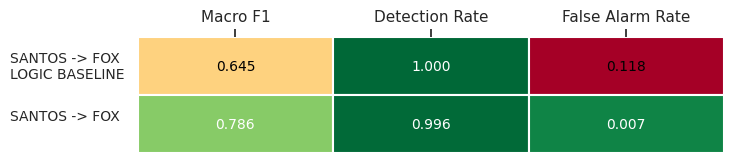

In [285]:
top_models = [
    "dpl_santos_fox_logic_baseline",
    "dpl_santos_fox_scratch",
]

metrics_heatmap(
    experiments,
    selected_models=top_models,
    # plots_title="Logic Baseline",
    global_bounds=bounds,
    plots_dir=plots_dir,
    plots_name="logic_baseline"
)

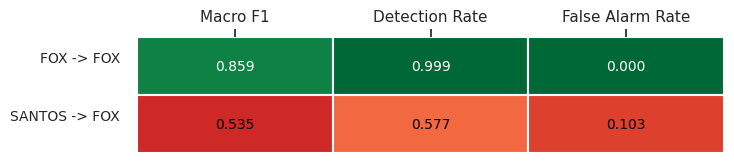

In [286]:
top_models = [
    "baseline_fox",
    "baseline_santos_fox",
]

metrics_heatmap(
    experiments,
    selected_models=top_models,
    # plots_title="Neural Baseline",
    global_bounds=bounds, 
    plots_dir=plots_dir,
    plots_name="neural_baseline"
)

## Metrics

In [287]:
experiments_df = pd.DataFrame(experiments).T
experiments_df

,f1_score,false_alarm_rate,detection_rate
dpl_fox_pretrained,0.879815,0.000044,0.999017
dpl_santos_fox_logic_baseline,0.644686,0.117906,0.999846
dpl_santos_fox_pretrained,0.503946,0.000370,0.476071
dpl_fox_scratch,0.702474,0.000887,0.992733
dpl_santos_fox_scratch,0.785626,0.007227,0.995913
baseline_fox,0.858518,0.000244,0.998841
baseline_santos_fox,0.535238,0.102994,0.577185


In [288]:
experiments_sorted = experiments_df.sort_values(by='f1_score', ascending=False)
experiments_sorted

,f1_score,false_alarm_rate,detection_rate
dpl_fox_pretrained,0.879815,0.000044,0.999017
baseline_fox,0.858518,0.000244,0.998841
dpl_santos_fox_scratch,0.785626,0.007227,0.995913
dpl_fox_scratch,0.702474,0.000887,0.992733
dpl_santos_fox_logic_baseline,0.644686,0.117906,0.999846
baseline_santos_fox,0.535238,0.102994,0.577185
dpl_santos_fox_pretrained,0.503946,0.000370,0.476071


In [289]:
# save sorted results to CSV
experiments_sorted.to_csv(plots_dir / "generalizability_results.csv", index=True)